<a href="https://colab.research.google.com/github/FOFM030711/SIMULACION-II/blob/main/Comportamiento%20a%20largo%20plazo%20CADENAS%20DE%20MARKOV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### COMPORTAMIENTO A LARGO PLAZO DE CADENAS DE MARKOV

Dada la matriz de probabilidad de transición $P$ y el estado inicial $π_0$ de una cadena de Markov, la distribucion en el tiempo siguiente se calcula como: $$π_0=π_1P$$

In [11]:
from sympy import *
init_printing(use_unicode=True)

In [21]:
from sympy import Rational
P=Matrix([[Rational('0.6'),Rational('0.4')],[Rational('0.2'),Rational('0.8')]])

In [29]:
Estado_Inicial=Matrix([[1,0]])

¿Cuál es el tipo de probabilidad en tiempo 1?

In [30]:
Estado_Inicial*Matriz_Transicion

[3/5  2/5]

Probabilidad de que el sábado llueva

In [31]:
sabado=Estado_Inicial*Matriz_Transicion**5

In [16]:
sabado

[0.34016  0.65984]

¿Cuál es probabilidad de que a largo plazo a un dia sea soleado?

Acompañe su respuesta con una gráfica

La probabilidad a largo plazo de un día soleado es: 1/2
La probabilidad a largo plazo de un día lluvioso es: 1/2
Distribución de estado estacionario: Matrix([[1/2, 1/2]])


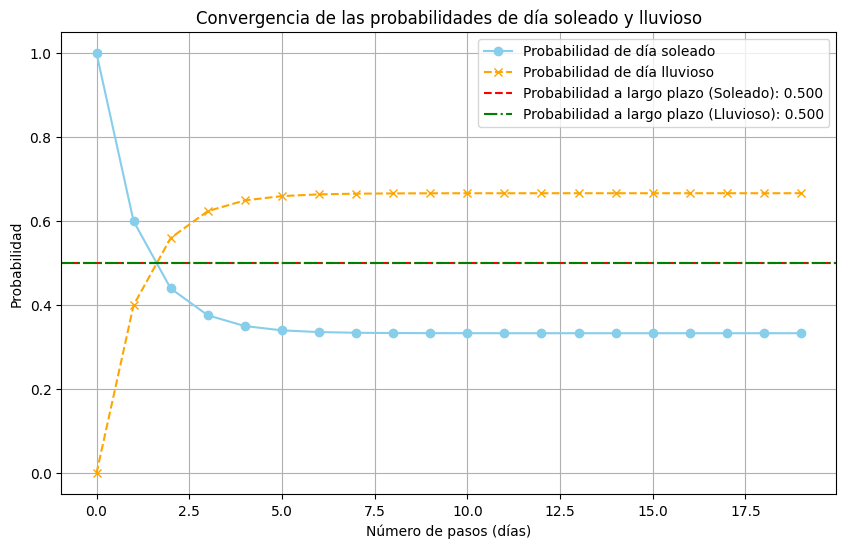

In [33]:
import matplotlib.pyplot as plt
from sympy import S

# Para una matriz estocástica, el valor propio 1 corresponde al vector de estado estacionario
v = [vecs for val, mult, vecs in Matriz_Transicion.eigenvects() if val == S.One]

if v:
    # Seleccionar el primer vector propio asociado al valor propio 1
    # El vector propio a menudo se devuelve como una lista de matrices, por lo que tomamos la primera.
    steady_state_vector = v[0][0]

    # Normalizar el vector propio para que la suma de sus elementos sea 1
    # Extraer los componentes del vector columna para realizar la suma
    components = [steady_state_vector[i, 0] for i in range(steady_state_vector.rows)]
    sum_components = sum(components)

    # Crear la distribución de estado estacionario normalizada como una matriz fila (como 'Estado_Inicial')
    steady_state_distribution = Matrix([[comp / sum_components for comp in components]])

    prob_sunny_long_term = steady_state_distribution[0] # El primer componente corresponde a "soleado"
    prob_rainy_long_term = steady_state_distribution[1] # El segundo componente corresponde a "lluvioso"

    print(f"La probabilidad a largo plazo de un día soleado es: {prob_sunny_long_term}")
    print(f"La probabilidad a largo plazo de un día lluvioso es: {prob_rainy_long_term}")
    print(f"Distribución de estado estacionario: {steady_state_distribution}")

    # Graficar la convergencia
    num_steps = 20
    sunny_probabilities_history = []
    rainy_probabilities_history = []
    current_p = Estado_Inicial

    for _ in range(num_steps):
        sunny_probabilities_history.append(float(current_p[0])) # Añadir la probabilidad de día soleado
        rainy_probabilities_history.append(float(current_p[1])) # Añadir la probabilidad de día lluvioso
        current_p = current_p * Matriz_Transicion

    plt.figure(figsize=(10, 6))
    plt.plot(range(num_steps), sunny_probabilities_history, marker='o', linestyle='-', color='skyblue', label='Probabilidad de día soleado')
    plt.plot(range(num_steps), rainy_probabilities_history, marker='x', linestyle='--', color='orange', label='Probabilidad de día lluvioso')
    plt.axhline(y=float(prob_sunny_long_term), color='r', linestyle='--', label=f'Probabilidad a largo plazo (Soleado): {float(prob_sunny_long_term):.3f}')
    plt.axhline(y=float(prob_rainy_long_term), color='g', linestyle='-.', label=f'Probabilidad a largo plazo (Lluvioso): {float(prob_rainy_long_term):.3f}')
    plt.title('Convergencia de las probabilidades de día soleado y lluvioso')
    plt.xlabel('Número de pasos (días)')
    plt.ylabel('Probabilidad')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No se encontró un vector de estado estacionario para el valor propio 1.")